In [15]:
# ============================================
# SIH26231 - Computer Vision Pipeline
# Digital Companion for Field Drug Testing
# ============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

print("OpenCV Version:", cv2.__version__)
print("NumPy Version:", np.__version__)

OpenCV Version: 5.0.0
NumPy Version: 2.1.3


Synthetic test image created!
Image Shape: (600, 800, 3)


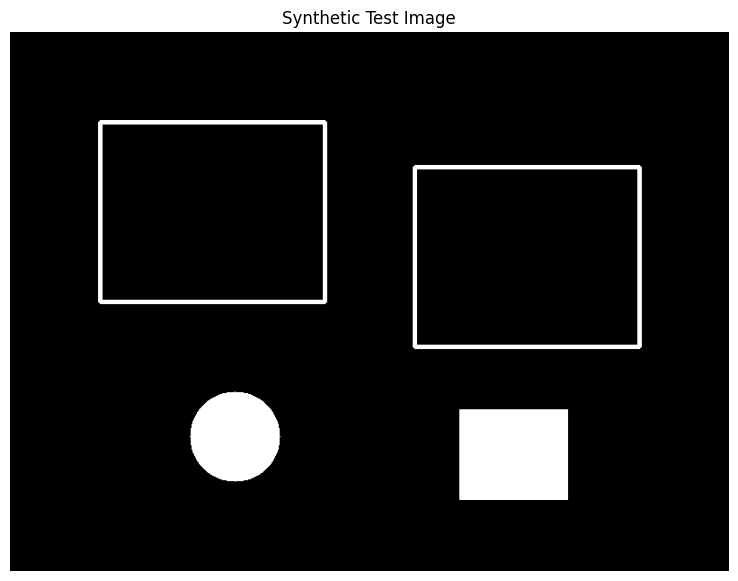

In [19]:
# ============================================
# CELL 2: Generate Synthetic Test Image
# ============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create black background
image = np.zeros((600, 800, 3), dtype=np.uint8)

# Draw white test regions
cv2.rectangle(image, (100, 100), (350, 300), (255, 255, 255), 3)
cv2.rectangle(image, (450, 150), (700, 350), (255, 255, 255), 3)

# Add a small filled circle
cv2.circle(image, (250, 450), 50, (255, 255, 255), -1)

# Add a small filled rectangle
cv2.rectangle(image, (500, 420), (620, 520), (255, 255, 255), -1)

print("Synthetic test image created!")
print("Image Shape:", image.shape)

# Display image
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Synthetic Test Image")
plt.show()

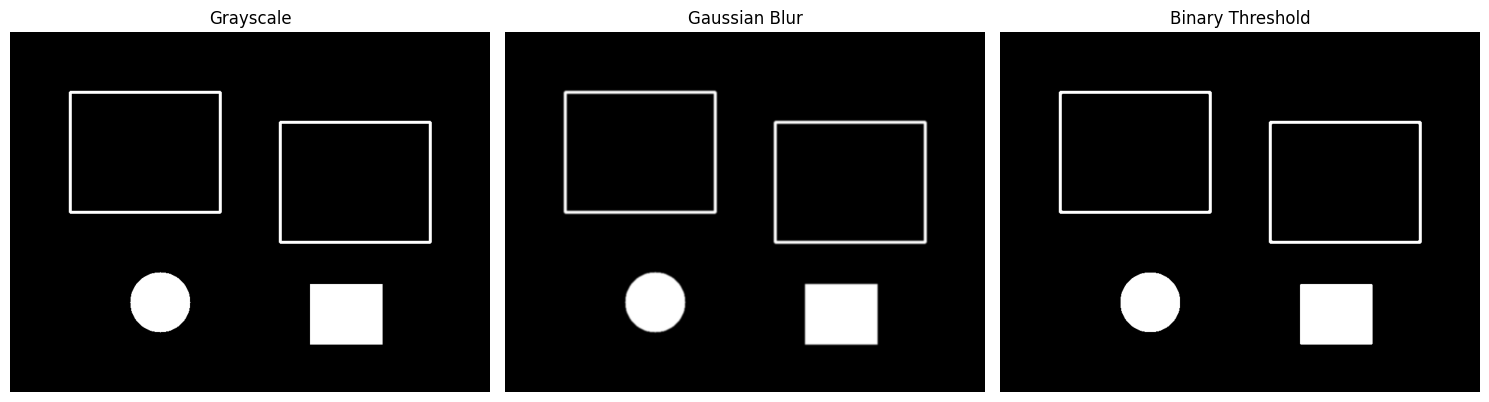

Image preprocessing completed!


In [20]:
# ============================================
# CELL 3: Image Preprocessing
# ============================================

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply binary threshold
_, threshold = cv2.threshold(
    blurred,
    127,
    255,
    cv2.THRESH_BINARY
)

# Display preprocessing stages
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(threshold, cmap="gray")
plt.title("Binary Threshold")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image preprocessing completed!")

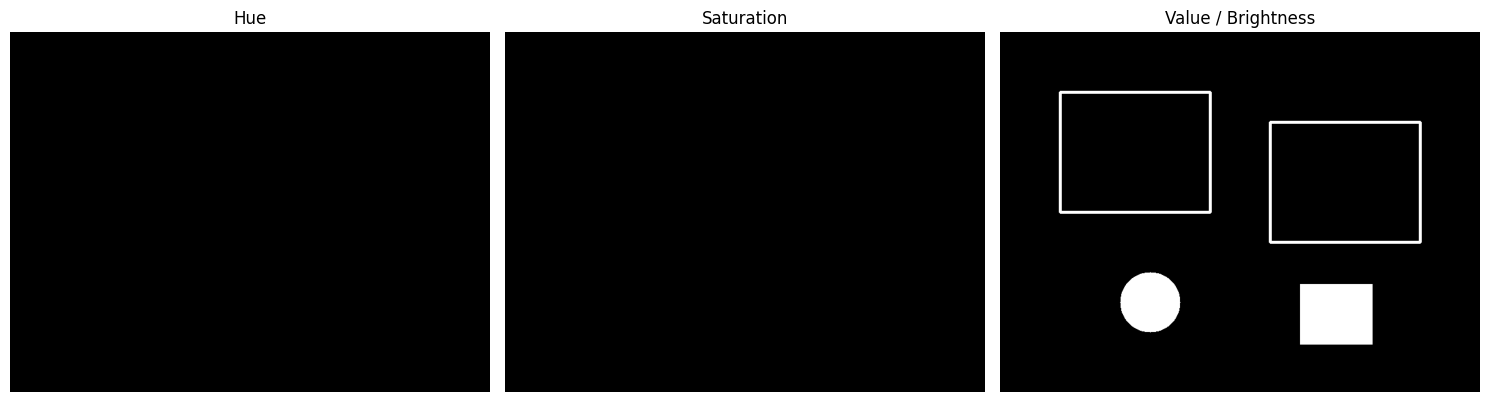

HSV colour analysis completed!

HSV Statistics:
Mean Hue: 0.0
Mean Saturation: 0.0
Mean Value: 15.4285625


In [22]:
# ============================================
# CELL 4: HSV Colour Analysis
# ============================================

# Convert BGR image to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Extract HSV channels
hue = hsv[:, :, 0]
saturation = hsv[:, :, 1]
value = hsv[:, :, 2]

# Display HSV channels
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(hue, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(saturation, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(value, cmap="gray")
plt.title("Value / Brightness")
plt.axis("off")

plt.tight_layout()
plt.show()

print("HSV colour analysis completed!")

print("\nHSV Statistics:")
print("Mean Hue:", np.mean(hue))
print("Mean Saturation:", np.mean(saturation))
print("Mean Value:", np.mean(value))

Laplacian Variance: 1286.41125
Image appears sharp enough.


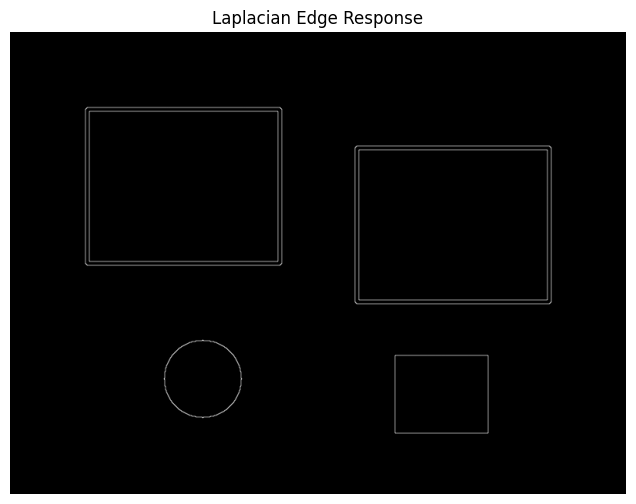

In [25]:
# ============================================
# CELL 5: Image Quality - Blur Detection
# ============================================

# Calculate Laplacian variance
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian_variance = laplacian.var()

print("Laplacian Variance:", laplacian_variance)

# Simple blur classification
blur_threshold = 100

if laplacian_variance < blur_threshold:
    print("Image may be blurry.")
else:
    print("Image appears sharp enough.")

# Visualize edges detected by Laplacian
plt.figure(figsize=(8, 6))
plt.imshow(np.abs(laplacian), cmap="gray")
plt.title("Laplacian Edge Response")
plt.axis("off")
plt.show()

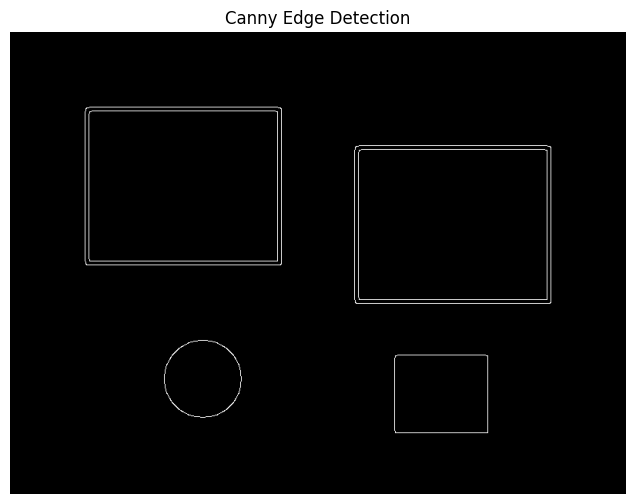

Canny edge detection completed!


In [26]:
# ============================================
# CELL 6: Canny Edge Detection
# ============================================

# Detect edges using Canny
edges = cv2.Canny(
    blurred,
    threshold1=50,
    threshold2=150
)

# Display edge image
plt.figure(figsize=(10, 6))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

print("Canny edge detection completed!")

Number of contours detected: 4
Contour 1: Area = 12210.00 | Perimeter = 441.66 | Corners = 4 | Bounding Box = (499, 419, 122, 102)
Contour 2: Area = 7874.00 | Perimeter = 332.05 | Corners = 8 | Bounding Box = (200, 400, 101, 101)
Contour 3: Area = 52254.00 | Perimeter = 915.31 | Corners = 4 | Bounding Box = (447, 147, 256, 206)
Contour 4: Area = 52254.00 | Perimeter = 915.31 | Corners = 4 | Bounding Box = (97, 97, 256, 206)


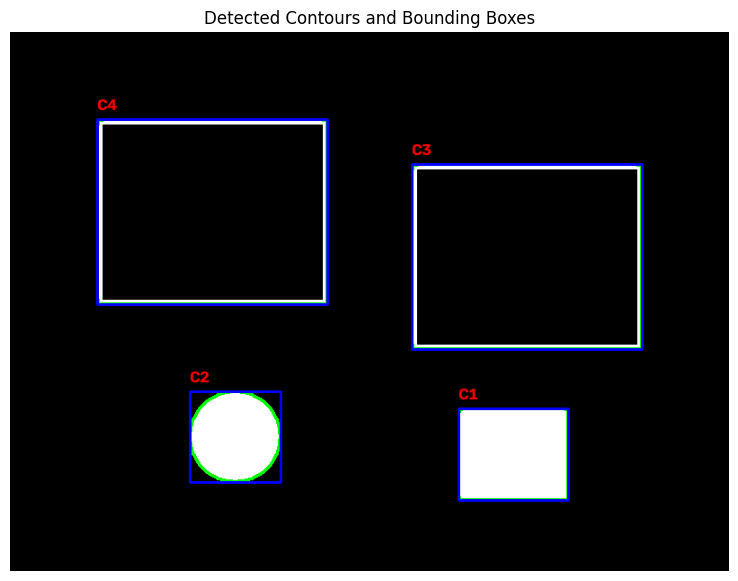

Contour analysis completed!


In [27]:
# ============================================
# CELL 7: Contour Detection
# ============================================

# Find contours from the edge image
contours, hierarchy = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours detected:", len(contours))

# Create a copy for drawing
contour_image = image.copy()

# Analyze each contour
for i, contour in enumerate(contours):

    # Calculate area
    area = cv2.contourArea(contour)

    # Calculate perimeter
    perimeter = cv2.arcLength(contour, True)

    # Approximate contour shape
    epsilon = 0.02 * perimeter
    approx = cv2.approxPolyDP(contour, epsilon, True)

    # Number of corners
    corners = len(approx)

    # Bounding rectangle
    x, y, w, h = cv2.boundingRect(contour)

    print(
        f"Contour {i+1}: "
        f"Area = {area:.2f} | "
        f"Perimeter = {perimeter:.2f} | "
        f"Corners = {corners} | "
        f"Bounding Box = ({x}, {y}, {w}, {h})"
    )

    # Draw contour
    cv2.drawContours(
        contour_image,
        [contour],
        -1,
        (0, 255, 0),
        2
    )

    # Draw bounding box
    cv2.rectangle(
        contour_image,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        2
    )

    # Label contour
    cv2.putText(
        contour_image,
        f"C{i+1}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2
    )

# Convert BGR → RGB for Matplotlib
contour_rgb = cv2.cvtColor(
    contour_image,
    cv2.COLOR_BGR2RGB
)

# Display result
plt.figure(figsize=(10, 7))
plt.imshow(contour_rgb)
plt.title("Detected Contours and Bounding Boxes")
plt.axis("off")
plt.show()

print("Contour analysis completed!")

Total contours: 4
Filtered contours: 4


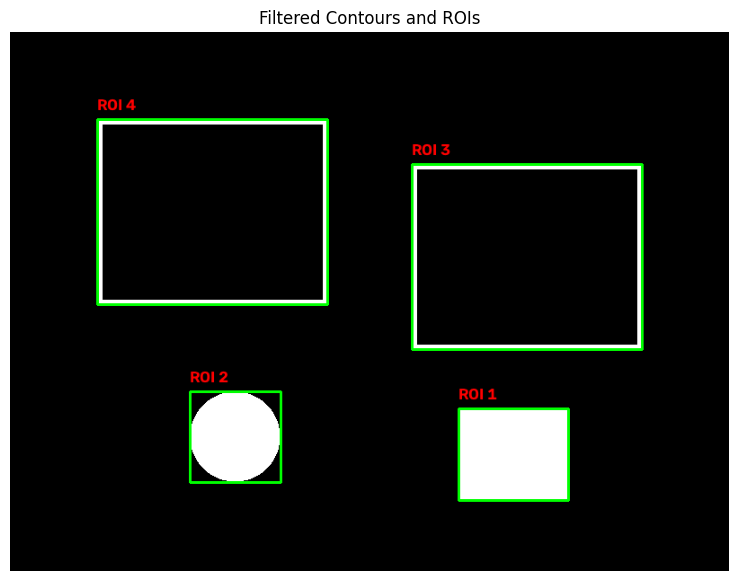

ROI extraction completed!
Number of ROIs: 4


In [29]:
# ============================================
# CELL 8: Contour Filtering & ROI Extraction
# ============================================

# Minimum contour area
MIN_AREA = 500

filtered_contours = []

for contour in contours:
    area = cv2.contourArea(contour)

    if area >= MIN_AREA:
        filtered_contours.append(contour)

print("Total contours:", len(contours))
print("Filtered contours:", len(filtered_contours))

# Create image for visualization
roi_image = image.copy()

rois = []

for i, contour in enumerate(filtered_contours):

    # Bounding rectangle
    x, y, w, h = cv2.boundingRect(contour)

    # Extract Region of Interest
    roi = image[y:y+h, x:x+w]

    rois.append(roi)

    # Draw bounding box
    cv2.rectangle(
        roi_image,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    # Label ROI
    cv2.putText(
        roi_image,
        f"ROI {i+1}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2
    )

# Display detected ROIs
roi_rgb = cv2.cvtColor(
    roi_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 7))
plt.imshow(roi_rgb)
plt.title("Filtered Contours and ROIs")
plt.axis("off")
plt.show()

print("ROI extraction completed!")
print("Number of ROIs:", len(rois))

In [30]:
# ============================================
# CELL 9: Feature Extraction from ROIs
# ============================================

features = []

for i, contour in enumerate(filtered_contours):

    # -----------------------------
    # Shape features
    # -----------------------------
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    x, y, w, h = cv2.boundingRect(contour)

    aspect_ratio = w / h if h != 0 else 0

    # -----------------------------
    # Extract ROI
    # -----------------------------
    roi = image[y:y+h, x:x+w]

    # Convert ROI to HSV
    roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

    # -----------------------------
    # Colour features
    # -----------------------------
    mean_hue = np.mean(roi_hsv[:, :, 0])
    mean_saturation = np.mean(roi_hsv[:, :, 1])
    mean_value = np.mean(roi_hsv[:, :, 2])

    # -----------------------------
    # Brightness
    # -----------------------------
    mean_brightness = np.mean(
        cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    )

    # Store features
    feature_row = {
        "ROI": i + 1,
        "Area": area,
        "Perimeter": perimeter,
        "Width": w,
        "Height": h,
        "Aspect_Ratio": aspect_ratio,
        "Mean_Hue": mean_hue,
        "Mean_Saturation": mean_saturation,
        "Mean_Value": mean_value,
        "Mean_Brightness": mean_brightness
    }

    features.append(feature_row)

# Convert to DataFrame
features_df = pd.DataFrame(features)

print("Feature extraction completed!")

print("\nExtracted Features:")
display(features_df)

Feature extraction completed!

Extracted Features:


,ROI,Area,Perimeter,Width,Height,Aspect_Ratio,Mean_Hue,Mean_Saturation,Mean_Value,Mean_Brightness
0,1,12210.0,441.656854,122,102,1.196078,0.0,0.0,250.430328,250.430328
1,2,7874.0,332.048773,101,101,1.000000,0.0,0.0,196.105774,196.105774
2,3,52254.0,915.313708,256,206,1.242718,0.0,0.0,21.701305,21.701305
3,4,52254.0,915.313708,256,206,1.242718,0.0,0.0,21.701305,21.701305


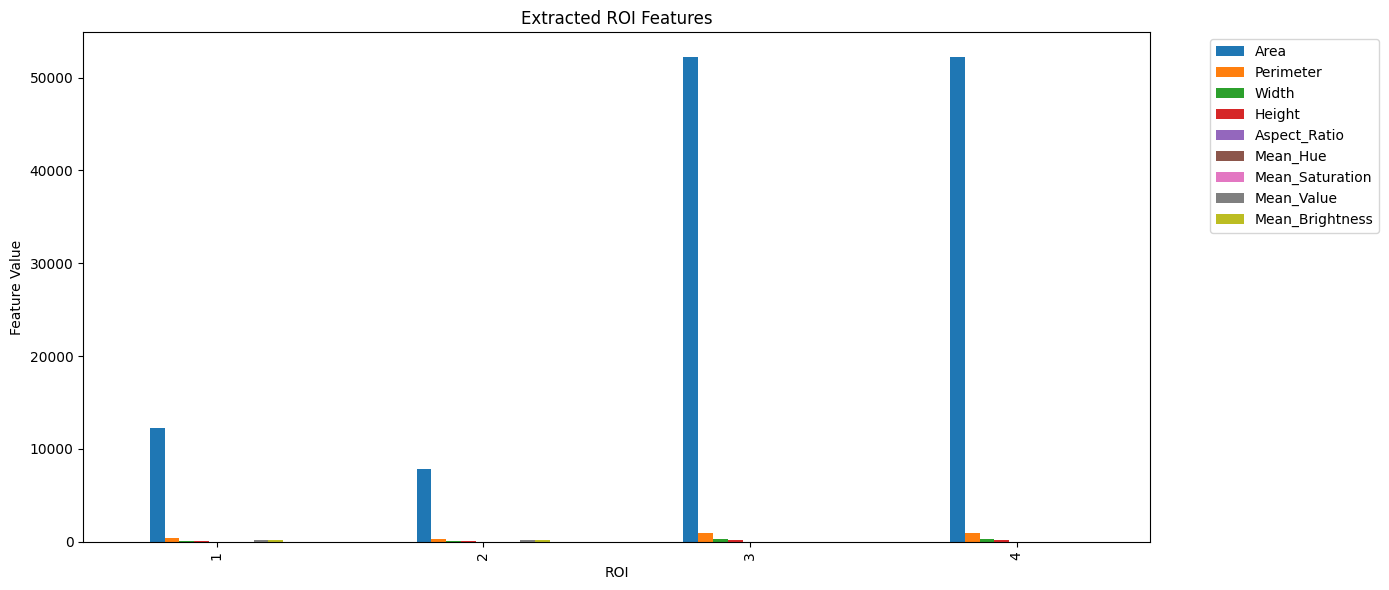

Feature visualization completed!


In [31]:
# ============================================
# CELL 10: Feature Visualization
# ============================================

# Select numerical features for visualization
numeric_features = [
    "Area",
    "Perimeter",
    "Width",
    "Height",
    "Aspect_Ratio",
    "Mean_Hue",
    "Mean_Saturation",
    "Mean_Value",
    "Mean_Brightness"
]

# Create feature plots
features_df[numeric_features].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Extracted ROI Features")
plt.xlabel("ROI")
plt.ylabel("Feature Value")
plt.xticks(
    range(len(features_df)),
    features_df["ROI"]
)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

print("Feature visualization completed!")

In [32]:
# ============================================
# CELL 11: Prepare Feature Dataset for ML
# ============================================

# Features that will be used by the ML model
feature_columns = [
    "Area",
    "Perimeter",
    "Width",
    "Height",
    "Aspect_Ratio",
    "Mean_Hue",
    "Mean_Saturation",
    "Mean_Value",
    "Mean_Brightness"
]

# Create feature matrix
X = features_df[feature_columns].copy()

print("Feature Matrix Shape:", X.shape)

print("\nFeature Matrix:")
display(X)

# Check for missing values
print("\nMissing Values:")
print(X.isnull().sum())

# Basic statistical summary
print("\nFeature Statistics:")
display(X.describe())

print("Feature dataset prepared!")

Feature Matrix Shape: (4, 9)

Feature Matrix:


,Area,Perimeter,Width,Height,Aspect_Ratio,Mean_Hue,Mean_Saturation,Mean_Value,Mean_Brightness
0,12210.0,441.656854,122,102,1.196078,0.0,0.0,250.430328,250.430328
1,7874.0,332.048773,101,101,1.000000,0.0,0.0,196.105774,196.105774
2,52254.0,915.313708,256,206,1.242718,0.0,0.0,21.701305,21.701305
3,52254.0,915.313708,256,206,1.242718,0.0,0.0,21.701305,21.701305



Missing Values:
Area               0
Perimeter          0
Width              0
Height             0
Aspect_Ratio       0
Mean_Hue           0
Mean_Saturation    0
Mean_Value         0
Mean_Brightness    0
dtype: int64

Feature Statistics:


,Area,Perimeter,Width,Height,Aspect_Ratio,Mean_Hue,Mean_Saturation,Mean_Value,Mean_Brightness
count,4.000000,4.000000,4.000000,4.000000,4.000000,4.0,4.0,4.000000,4.000000
mean,31148.000000,651.083261,183.750000,153.750000,1.170379,0.0,0.0,122.484678,122.484678
std,24435.311825,308.370926,83.866461,60.334484,0.115694,0.0,0.0,118.469028,118.469028
min,7874.000000,332.048773,101.000000,101.000000,1.000000,0.0,0.0,21.701305,21.701305
25%,11126.000000,414.254834,116.750000,101.750000,1.147059,0.0,0.0,21.701305,21.701305
50%,32232.000000,678.485281,189.000000,154.000000,1.219398,0.0,0.0,108.903539,108.903539
75%,52254.000000,915.313708,256.000000,206.000000,1.242718,0.0,0.0,209.686912,209.686912
max,52254.000000,915.313708,256.000000,206.000000,1.242718,0.0,0.0,250.430328,250.430328


Feature dataset prepared!


In [44]:
# ============================================
# CELL 12: Create SIH Synthetic Labelled Dataset
# ============================================

np.random.seed(42)

n_samples = 300

data = []

for i in range(n_samples):

    # Select class
    label = i % 3

    if label == 0:
        # Negative
        area = np.random.normal(8000, 1200)
        perimeter = np.random.normal(350, 40)
        width = np.random.normal(100, 10)
        height = np.random.normal(100, 10)
        aspect_ratio = np.random.normal(1.0, 0.08)

        hue = np.random.normal(60, 10)
        saturation = np.random.normal(40, 10)
        value = np.random.normal(180, 20)
        brightness = np.random.normal(180, 20)

    elif label == 1:
        # Positive
        area = np.random.normal(30000, 4000)
        perimeter = np.random.normal(700, 60)
        width = np.random.normal(200, 20)
        height = np.random.normal(150, 15)
        aspect_ratio = np.random.normal(1.3, 0.1)

        hue = np.random.normal(120, 10)
        saturation = np.random.normal(180, 20)
        value = np.random.normal(200, 15)
        brightness = np.random.normal(200, 15)

    else:
        # Inconclusive
        area = np.random.normal(18000, 3000)
        perimeter = np.random.normal(500, 50)
        width = np.random.normal(150, 15)
        height = np.random.normal(130, 15)
        aspect_ratio = np.random.normal(1.15, 0.1)

        hue = np.random.normal(30, 15)
        saturation = np.random.normal(100, 20)
        value = np.random.normal(120, 25)
        brightness = np.random.normal(120, 25)

    data.append([
        area,
        perimeter,
        width,
        height,
        aspect_ratio,
        hue,
        saturation,
        value,
        brightness,
        label
    ])

# Create DataFrame

synthetic_df = pd.DataFrame(
    data,
    columns=[
        "Area",
        "Perimeter",
        "Width",
        "Height",
        "Aspect_Ratio",
        "Mean_Hue",
        "Mean_Saturation",
        "Mean_Value",
        "Mean_Brightness",
        "Label"
    ]
)

print("✅ SIH synthetic labelled dataset created!")

print("\nDataset Shape:")
print(synthetic_df.shape)

print("\nClass Distribution:")
print(synthetic_df["Label"].value_counts().sort_index())

display(synthetic_df.head())

✅ SIH synthetic labelled dataset created!

Dataset Shape:
(300, 10)

Class Distribution:
Label
0    100
1    100
2    100
Name: count, dtype: int64


,Area,Perimeter,Width,Height,Aspect_Ratio,Mean_Hue,Mean_Saturation,Mean_Value,Mean_Brightness,Label
0,8596.056984,344.469428,106.476885,115.230299,0.981268,57.658630,55.792128,195.348695,170.610512,0
1,32170.240174,672.194938,190.685405,153.629434,1.108672,102.750822,168.754249,184.807533,204.713710,1
2,15275.927773,429.384815,171.984732,126.613355,1.156753,8.628777,89.112346,122.773065,91.225161,2
3,8450.837622,325.974452,97.083063,93.982934,1.148182,59.865028,29.422891,196.450898,155.583127,0
4,30835.454380,582.419793,173.436279,152.952919,1.373847,121.713683,177.687034,195.483445,177.822170,1


In [45]:
# ============================================
# CELL 13: Train/Test Split & Scaling
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = synthetic_df[
    feature_columns
]

y = synthetic_df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("\nOriginal training shape:", X_train.shape)
print("Scaled training shape:", X_train_scaled.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Scaled testing shape:", X_test_scaled.shape)

print("\n✅ Train/test split and scaling completed!")

Training samples: 240
Testing samples: 60

Original training shape: (240, 9)
Scaled training shape: (240, 9)

Original testing shape: (60, 9)
Scaled testing shape: (60, 9)

✅ Train/test split and scaling completed!


In [47]:
# ============================================
# CELL 14: Train Multiple ML Models
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            kernel="rbf",
            probability=True
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
}

for name, model in models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    print(
        f"{name} trained successfully!"
    )

print("\nAll models trained successfully!")

Logistic Regression trained successfully!
KNN trained successfully!
SVM trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!

All models trained successfully!


In [48]:
# ============================================
# CELL 14: Train Multiple ML Models
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            kernel="rbf",
            probability=True
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
}

for name, model in models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    print(
        f"{name} trained successfully!"
    )

print("\nAll models trained successfully!")

Logistic Regression trained successfully!
KNN trained successfully!
SVM trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!

All models trained successfully!


In [49]:
# ============================================
# CELL 15: Model Evaluation
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    y_pred = model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(results_df)

print("Model evaluation completed!")

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,KNN,1.000000,1.000000,1.000000,1.000000
2,SVM,1.000000,1.000000,1.000000,1.000000
3,Random Forest,1.000000,1.000000,1.000000,1.000000
4,Decision Tree,0.933333,0.936027,0.933333,0.933166


Model evaluation completed!


Best Model: Logistic Regression

Confusion Matrix:
[[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]


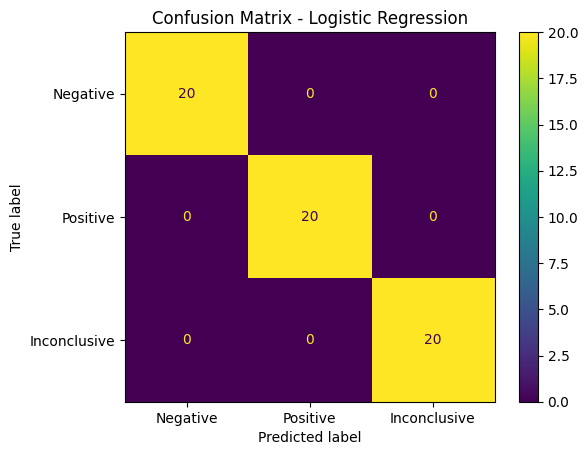

Confusion matrix generated!


In [50]:
# ============================================
# CELL 16: Best Model & Confusion Matrix
# ============================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Select best model based on F1 score
best_model_name = results_df.iloc[0]["Model"]

best_model = models[
    best_model_name
]

# Predictions
y_pred_best = best_model.predict(
    X_test_scaled
)

print("Best Model:", best_model_name)

# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_best
)

print("\nConfusion Matrix:")
print(cm)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive",
        "Inconclusive"
    ]
)

disp.plot()

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

print("Confusion matrix generated!")

In [51]:
# ============================================
# CELL 17: Classification Report
# ============================================

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred_best,
    target_names=[
        "Negative",
        "Positive",
        "Inconclusive"
    ],
    zero_division=0
)

print(
    f"Classification Report - {best_model_name}"
)

print("=" * 55)

print(report)

print("Classification report generated!")

Classification Report - Logistic Regression
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        20
    Positive       1.00      1.00      1.00        20
Inconclusive       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

Classification report generated!


,Feature,Importance
7,Mean_Value,0.011667
5,Mean_Hue,0.010000
8,Mean_Brightness,0.006667
0,Area,0.000000
1,Perimeter,0.000000
4,Aspect_Ratio,0.000000
3,Height,0.000000
2,Width,0.000000
6,Mean_Saturation,0.000000


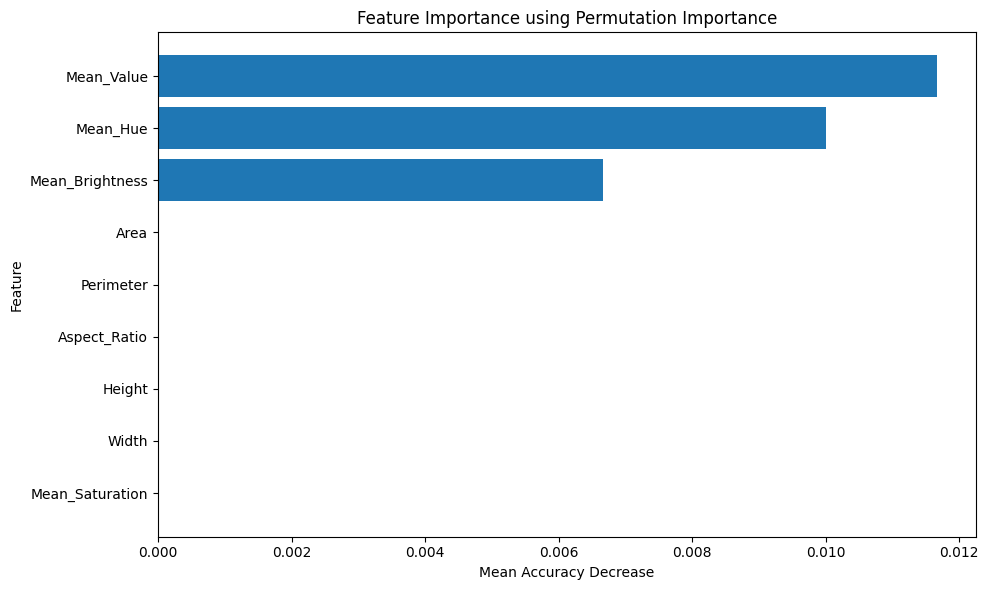

Feature importance analysis completed!


In [52]:
# ============================================
# CELL 18: Feature Importance
# ============================================

from sklearn.inspection import permutation_importance

importance = permutation_importance(
    best_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": importance.importances_mean
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df)

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel(
    "Mean Accuracy Decrease"
)

plt.ylabel("Feature")

plt.title(
    "Feature Importance using Permutation Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

print("Feature importance analysis completed!")

In [53]:
# ============================================
# CELL 19: End-to-End CV + ML Prediction
# ============================================

def predict_image(image, model, scaler):

    # ----------------------------------------
    # 1. Grayscale
    # ----------------------------------------
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # ----------------------------------------
    # 2. Blur
    # ----------------------------------------
    blurred = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    # ----------------------------------------
    # 3. Canny
    # ----------------------------------------
    edges = cv2.Canny(
        blurred,
        50,
        150
    )

    # ----------------------------------------
    # 4. Contours
    # ----------------------------------------
    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    predictions = []

    labels = {
        0: "Negative",
        1: "Positive",
        2: "Inconclusive"
    }

    # ----------------------------------------
    # 5. Process contours
    # ----------------------------------------
    for contour in contours:

        area = cv2.contourArea(
            contour
        )

        if area < 500:
            continue

        perimeter = cv2.arcLength(
            contour,
            True
        )

        x, y, w, h = cv2.boundingRect(
            contour
        )

        aspect_ratio = (
            w / h
            if h != 0
            else 0
        )

        # ROI
        roi = image[
            y:y+h,
            x:x+w
        ]

        if roi.size == 0:
            continue

        # HSV
        roi_hsv = cv2.cvtColor(
            roi,
            cv2.COLOR_BGR2HSV
        )

        mean_hue = np.mean(
            roi_hsv[:, :, 0]
        )

        mean_saturation = np.mean(
            roi_hsv[:, :, 1]
        )

        mean_value = np.mean(
            roi_hsv[:, :, 2]
        )

        # Brightness
        mean_brightness = np.mean(
            cv2.cvtColor(
                roi,
                cv2.COLOR_BGR2GRAY
            )
        )

        # ------------------------------------
        # 6. Feature DataFrame
        # ------------------------------------
        feature_vector = pd.DataFrame([{
            "Area": area,
            "Perimeter": perimeter,
            "Width": w,
            "Height": h,
            "Aspect_Ratio": aspect_ratio,
            "Mean_Hue": mean_hue,
            "Mean_Saturation": mean_saturation,
            "Mean_Value": mean_value,
            "Mean_Brightness": mean_brightness
        }])

        # ------------------------------------
        # 7. Scaling
        # ------------------------------------
        feature_scaled = scaler.transform(
            feature_vector
        )

        # ------------------------------------
        # 8. Prediction
        # ------------------------------------
        prediction = model.predict(
            feature_scaled
        )[0]

        predicted_label = labels[
            prediction
        ]

        predictions.append({
            "Bounding_Box": (
                x, y, w, h
            ),
            "Area": area,
            "Prediction": predicted_label
        })

    return predictions


# ============================================
# Run final prediction
# ============================================

predictions = predict_image(
    image,
    best_model,
    scaler
)

print("Prediction Results:")
print("=" * 50)

if len(predictions) == 0:

    print(
        "⚠️ No meaningful regions detected."
    )

else:

    for i, result in enumerate(
        predictions
    ):

        print(f"\nROI {i + 1}")

        print(
            "Bounding Box:",
            result["Bounding_Box"]
        )

        print(
            "Area:",
            round(result["Area"], 2)
        )

        print(
            "Prediction:",
            result["Prediction"]
        )

print(
    "\nEnd-to-end prediction completed!"
)

Prediction Results:

ROI 1
Bounding Box: (499, 419, 122, 102)
Area: 12210.0
Prediction: Negative

ROI 2
Bounding Box: (200, 400, 101, 101)
Area: 7874.0
Prediction: Negative

ROI 3
Bounding Box: (447, 147, 256, 206)
Area: 52254.0
Prediction: Inconclusive

ROI 4
Bounding Box: (97, 97, 256, 206)
Area: 52254.0
Prediction: Inconclusive

End-to-end prediction completed!


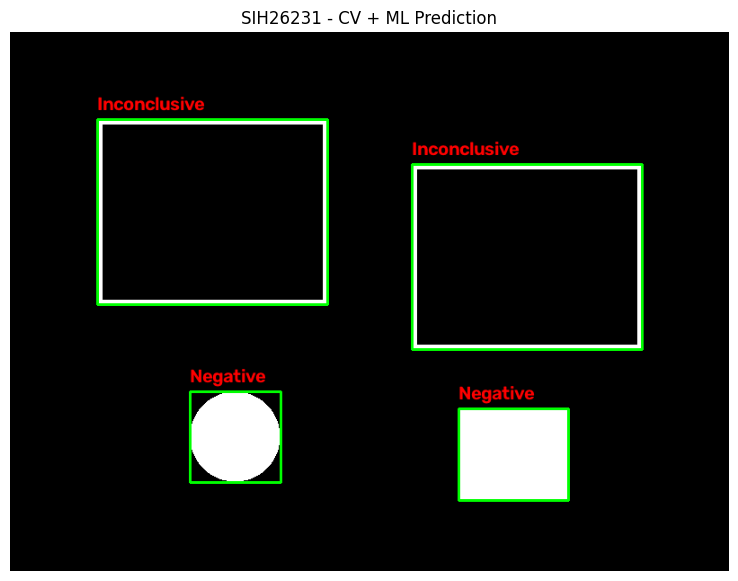

Final visual prediction generated!


In [54]:
# ============================================
# CELL 20: Visualize Final Predictions
# ============================================

result_image = image.copy()

for i, result in enumerate(predictions):

    x, y, w, h = result[
        "Bounding_Box"
    ]

    label = result[
        "Prediction"
    ]

    # Bounding box
    cv2.rectangle(
        result_image,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    # Label
    cv2.putText(
        result_image,
        label,
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 0, 255),
        2
    )

# Convert BGR → RGB
result_rgb = cv2.cvtColor(
    result_image,
    cv2.COLOR_BGR2RGB
)

# Display
plt.figure(figsize=(10, 7))

plt.imshow(result_rgb)

plt.title(
    "SIH26231 - CV + ML Prediction"
)

plt.axis("off")

plt.show()

print(
    "Final visual prediction generated!"
)

In [55]:
# ============================================
# CELL 21: Save Trained Model
# ============================================

import joblib

# Save trained model
joblib.dump(
    best_model,
    "sih26231_svm_model.pkl"
)

# Save scaler
joblib.dump(
    scaler,
    "sih26231_scaler.pkl"
)

print("Model saved successfully!")
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


In [57]:
# ============================================
# CELL 22: Reload Saved Model
# ============================================

import joblib

# Load trained model
loaded_model = joblib.load(
    "sih26231_svm_model.pkl"
)

# Load scaler
loaded_scaler = joblib.load(
    "sih26231_scaler.pkl"
)

print("Model loaded successfully!")
print("Scaler loaded successfully!")

# Verify model type
print("\nLoaded Model:")
print(loaded_model)

print("\nLoaded Scaler:")
print(loaded_scaler)

Model loaded successfully!
Scaler loaded successfully!

Loaded Model:
LogisticRegression(max_iter=1000)

Loaded Scaler:
StandardScaler()


In [58]:
# ============================================
# CELL 23: Final Prediction Using Saved Model
# ============================================

final_predictions = predict_image(
    image,
    loaded_model,
    loaded_scaler
)

print("Final Prediction Results:")
print("=" * 50)

if len(final_predictions) == 0:

    print("No meaningful regions detected.")

else:

    for i, result in enumerate(final_predictions):

        print(f"\nROI {i + 1}")

        print(
            "Bounding Box:",
            result["Bounding_Box"]
        )

        print(
            "Area:",
            round(result["Area"], 2)
        )

        print(
            "Prediction:",
            result["Prediction"]
        )

print("\nFinal prediction pipeline completed!")

Final Prediction Results:

ROI 1
Bounding Box: (499, 419, 122, 102)
Area: 12210.0
Prediction: Negative

ROI 2
Bounding Box: (200, 400, 101, 101)
Area: 7874.0
Prediction: Negative

ROI 3
Bounding Box: (447, 147, 256, 206)
Area: 52254.0
Prediction: Inconclusive

ROI 4
Bounding Box: (97, 97, 256, 206)
Area: 52254.0
Prediction: Inconclusive

Final prediction pipeline completed!


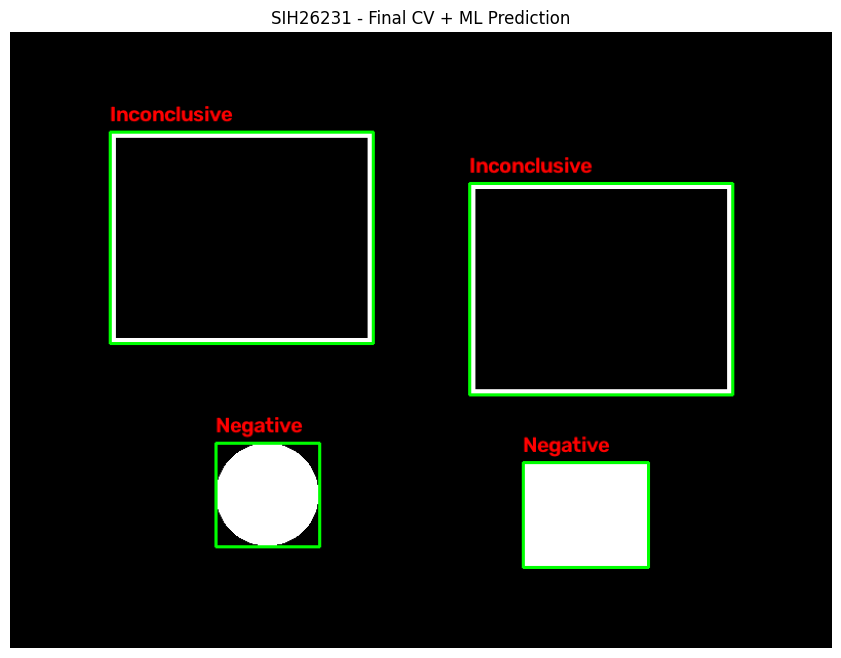

Final visual prediction generated!


In [59]:
# ============================================
# CELL 24: Final Visual Prediction
# ============================================

final_image = image.copy()

for i, result in enumerate(final_predictions):

    x, y, w, h = result["Bounding_Box"]
    label = result["Prediction"]

    # Draw bounding box
    cv2.rectangle(
        final_image,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    # Draw prediction label
    cv2.putText(
        final_image,
        label,
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 0, 255),
        2
    )

# Convert BGR to RGB
final_image_rgb = cv2.cvtColor(
    final_image,
    cv2.COLOR_BGR2RGB
)

# Display final result
plt.figure(figsize=(12, 8))

plt.imshow(final_image_rgb)

plt.title(
    "SIH26231 - Final CV + ML Prediction"
)

plt.axis("off")
plt.show()

print("Final visual prediction generated!")

In [60]:
# ============================================
# CELL 25: Save Final Model Files
# ============================================

import joblib

joblib.dump(
    loaded_model,
    "sih26231_model.pkl"
)

joblib.dump(
    loaded_scaler,
    "sih26231_scaler.pkl"
)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
